In [4]:
import random
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# ============================================
# 1. SETUP AND DATA LOADING
# ============================================

seed = 42
random.seed(seed)
np.random.seed(seed)
print(f"Global random seeds for 'random' and 'numpy' set to {seed}.")

# Data Loading and Preprocessing
# df_stoxx is already prepared and cleaned from previous steps in the notebook history
if 'df_stoxx' not in locals() and 'df_stoxx' not in globals():
    df_stoxx = pd.read_csv('SU.csv', parse_dates=['Date'])
    df_stoxx = df_stoxx.set_index('Date').sort_index()
    df_stoxx['SU_Close'] = df_stoxx['SU_Close'].ffill()

# Extract target column and split data
test_size = 30
train_series = df_stoxx[:-test_size]['SU_Close']
test_series = df_stoxx[-test_size:]['SU_Close']

print(f"Training data: {len(train_series)} days")
print(f"Test data: {len(test_series)} days")

# Define window parameters
n_future_steps_per_block_val = 5



Global random seeds for 'random' and 'numpy' set to 42.
Training data: 2781 days
Test data: 30 days


In [6]:
# ============================================
# 2. SLIDING WINDOW FUNCTION
# ============================================

def create_sliding_windows(series, n_lags, n_future_steps):
    X, y = [], []
    for i in range(len(series) - n_lags - n_future_steps + 1):
        X.append(series.iloc[i:i + n_lags].values)
        y.append(series.iloc[i + n_lags:i + n_lags + n_future_steps].values)
    return np.array(X), np.array(y)


In [7]:
# ============================================
# 3. HYPERPARAMETER TUNING
# ============================================

# Define candidates for n_lags_val
n_lags_val_candidates = [22, 66, 132]
all_cv_results = []

print("\nStarting Hyperparameter Tuning including n_lags_val...")

for n_lags_val in n_lags_val_candidates:
    print(f"\n--- Tuning for n_lags_val = {n_lags_val} ---")

    # Generate training windows
    X_train_sliding_np, y_train_sliding_np = create_sliding_windows(
        train_series, n_lags_val, n_future_steps_per_block_val
    )

    # Create DataFrames with informative column names
    x_train_cols = [f'SU_Close_lag_{i+1}' for i in range(n_lags_val)]
    y_train_cols = [f'SU_Close_future_{i+1}' for i in range(n_future_steps_per_block_val)]

    X_train_sliding = pd.DataFrame(
        X_train_sliding_np,
        columns=x_train_cols,
        index=train_series.index[n_lags_val:len(train_series) - n_future_steps_per_block_val + 1]
    )
    y_train_sliding = pd.DataFrame(
        y_train_sliding_np,
        columns=y_train_cols,
        index=train_series.index[n_lags_val:len(train_series) - n_future_steps_per_block_val + 1]
    )

    # NO SCALING - use raw data directly
    X_train_raw = X_train_sliding
    y_train_raw = y_train_sliding

    print(f"Training shapes - X: {X_train_raw.shape}, y: {y_train_raw.shape}")

    # Define XGBoost Model
    xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1)
    multioutput_model = MultiOutputRegressor(estimator=xgb_regressor, n_jobs=-1)

    # Hyperparameter Tuning with Grid Search for XGBoost parameters
    param_grid = {
        'estimator__n_estimators': [100, 200],
        'estimator__learning_rate': [0.01, 0.1, 0.2],
        'estimator__max_depth': [3, 5, 7]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    grid_search = GridSearchCV(
        estimator=multioutput_model,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )

    print(f"Running GridSearchCV for n_lags_val={n_lags_val}...")
    grid_search.fit(X_train_raw, y_train_raw)

    # Collect results and add n_lags_val
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df['n_lags_val'] = n_lags_val
    all_cv_results.append(results_df)

    print(f"Best hyperparameters for n_lags_val={n_lags_val}: {grid_search.best_params_}")
    print(f"Best CV RMSE for n_lags_val={n_lags_val}: {-grid_search.best_score_:.6f}")



Starting Hyperparameter Tuning including n_lags_val...

--- Tuning for n_lags_val = 22 ---
Training shapes - X: (2755, 22), y: (2755, 5)
Running GridSearchCV for n_lags_val=22...
Best hyperparameters for n_lags_val=22: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}
Best CV RMSE for n_lags_val=22: 4.600419

--- Tuning for n_lags_val = 66 ---
Training shapes - X: (2711, 66), y: (2711, 5)
Running GridSearchCV for n_lags_val=66...
Best hyperparameters for n_lags_val=66: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}
Best CV RMSE for n_lags_val=66: 5.161559

--- Tuning for n_lags_val = 132 ---
Training shapes - X: (2645, 132), y: (2645, 5)
Running GridSearchCV for n_lags_val=132...
Best hyperparameters for n_lags_val=132: {'estimator__learning_rate': 0.2, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}
Best CV RMSE for n_lags_val=132: 4.705986


In [8]:
# ============================================
# 4. SELECT BEST PARAMETERS
# ============================================

# Consolidate and Display All Hyperparameter Combinations
full_results_df = pd.concat(all_cv_results, ignore_index=True)
full_results_df['mean_test_rmse'] = -full_results_df['mean_test_score']

# Sort by RMSE to find the best overall
full_results_df_sorted = full_results_df.sort_values(by='mean_test_rmse').reset_index(drop=True)

print("\n--- Consolidated Grid Search Results (Sorted by Mean Validation RMSE) ---")
display_cols = [
    'param_estimator__n_estimators',
    'param_estimator__learning_rate',
    'param_estimator__max_depth',
    'n_lags_val',
    'mean_test_rmse'
]
print(full_results_df_sorted[display_cols].to_string(index=False))
print("------------------------------------------------------------------------\n")

# Identify the overall best parameters
best_overall_row = full_results_df_sorted.iloc[0]
best_n_lags_val = int(best_overall_row['n_lags_val'])
best_n_estimators = int(best_overall_row['param_estimator__n_estimators'])
best_learning_rate = float(best_overall_row['param_estimator__learning_rate'])
best_max_depth = int(best_overall_row['param_estimator__max_depth'])
overall_best_rmse = best_overall_row['mean_test_rmse']

print(f"Overall Best n_lags_val: {best_n_lags_val}")
print(f"Overall Best XGBoost Hyperparameters: n_estimators={best_n_estimators}, learning_rate={best_learning_rate}, max_depth={best_max_depth}")
print(f"Overall Best Mean Validation RMSE: {overall_best_rmse:.4f}")


--- Consolidated Grid Search Results (Sorted by Mean Validation RMSE) ---
 param_estimator__n_estimators  param_estimator__learning_rate  param_estimator__max_depth  n_lags_val  mean_test_rmse
                           100                            0.10                           3          22        4.600419
                           200                            0.10                           3          22        4.638635
                           100                            0.20                           3         132        4.705986
                           200                            0.10                           3         132        4.715547
                           100                            0.20                           3          22        4.726010
                           200                            0.20                           3         132        4.737632
                           100                            0.10                           3  

In [9]:
# ============================================
# 5. RECURSIVE RETRAINING STRATEGY
# ============================================

print("\n" + "="*60)
print("STARTING RECURSIVE RETRAINING STRATEGY")
print("="*60)

# Store predictions and actuals
all_predictions = []
all_actuals = []
block_metrics = []

# Start with initial training data
current_train = train_series.copy()

# Number of 5-day blocks in test set
num_test_blocks = test_size // n_future_steps_per_block_val

print(f"\nNumber of test blocks: {num_test_blocks}")
print(f"Forecasting {num_test_blocks * n_future_steps_per_block_val} days total")

# Loop through each 5-day block
for block in range(num_test_blocks):
    print(f"\n{'='*50}")
    print(f"BLOCK {block+1}/{num_test_blocks}")
    print(f"{'='*50}")
    
    # 1. Get actual values for this block
    start_idx = block * n_future_steps_per_block_val
    end_idx = (block + 1) * n_future_steps_per_block_val
    actual_block = test_series.iloc[start_idx:end_idx]
    
    print(f"Training size: {len(current_train)} days")
    print(f"Predicting test days {start_idx+1} to {end_idx}")
    
    # 2. Create training windows from CURRENT training data
    X_train_np, y_train_np = create_sliding_windows(
        current_train, 
        best_n_lags_val, 
        n_future_steps_per_block_val
    )
    
    if len(X_train_np) == 0:
        print(f"Warning: Not enough data to create windows. Need at least {best_n_lags_val + n_future_steps_per_block_val} days.")
        break
    
    # NO SCALING - use raw data directly
    X_train_raw = X_train_np
    y_train_raw = y_train_np
    
    # 3. Train model with best parameters
    print(f"Training model on {len(current_train)} days...")
    block_model = MultiOutputRegressor(
        xgb.XGBRegressor(
            n_estimators=best_n_estimators,
            learning_rate=best_learning_rate,
            max_depth=best_max_depth,
            objective='reg:squarederror',
            random_state=seed,
            n_jobs=-1
        ),
        n_jobs=-1
    )
    
    block_model.fit(X_train_raw, y_train_raw)
    
    # 4. Get the last n_lags days for prediction
    last_n_days = current_train[-best_n_lags_val:].values.reshape(1, -1)
    
    # 5. Make prediction for next 5 days (NO SCALING, NO INVERSE TRANSFORM)
    predictions = block_model.predict(last_n_days).flatten()
    
    # 6. Store results
    all_predictions.append(predictions)
    all_actuals.append(actual_block.values)
    
    # 7. Calculate block performance
    block_rmse = np.sqrt(mean_squared_error(actual_block.values, predictions))
    block_mae = mean_absolute_error(actual_block.values, predictions)
    
    block_metrics.append({
        'block': block + 1,
        'training_size': len(current_train),
        'rmse': block_rmse,
        'mae': block_mae
    })
    
    print(f"Predictions: {predictions.round(2)}")
    print(f"Actuals:     {actual_block.values.round(2)}")
    print(f"Block RMSE: {block_rmse:.2f}, MAE: {block_mae:.2f}")
    
    # 8. ADD ACTUAL VALUES TO TRAINING DATA FOR NEXT BLOCK
    # (Only if there are more blocks to predict)
    if block < num_test_blocks - 1:
        # Get the actual dates and values
        new_dates = actual_block.index
        new_values = pd.Series(actual_block.values, index=new_dates)
        
        # Add to training data
        current_train = pd.concat([current_train, new_values])
        print(f"Added {len(new_values)} actual days to training data")




STARTING RECURSIVE RETRAINING STRATEGY

Number of test blocks: 6
Forecasting 30 days total

BLOCK 1/6
Training size: 2781 days
Predicting test days 1 to 5
Training model on 2781 days...
Predictions: [63.2  63.25 63.32 63.42 63.35]
Actuals:     [64.36 63.96 63.4  62.88 63.48]
Block RMSE: 0.66, MAE: 0.52
Added 5 actual days to training data

BLOCK 2/6
Training size: 2786 days
Predicting test days 6 to 10
Training model on 2786 days...
Predictions: [63.62 63.37 63.25 63.05 62.64]
Actuals:     [62.24 62.46 63.62 63.   63.42]
Block RMSE: 0.83, MAE: 0.70
Added 5 actual days to training data

BLOCK 3/6
Training size: 2791 days
Predicting test days 11 to 15
Training model on 2791 days...
Predictions: [63.65 63.67 63.55 63.67 63.19]
Actuals:     [64.34 64.28 65.44 64.4  63.52]
Block RMSE: 1.01, MAE: 0.85
Added 5 actual days to training data

BLOCK 4/6
Training size: 2796 days
Predicting test days 16 to 20
Training model on 2796 days...
Predictions: [63.62 63.74 63.63 63.62 63.24]
Actuals:     

In [10]:
# ============================================
# 6. COMBINE AND EVALUATE RESULTS
# ============================================

# Flatten predictions and actuals
all_predictions_flat = np.concatenate(all_predictions)
all_actuals_flat = np.concatenate(all_actuals)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': all_actuals_flat,
    'XGBoost_Predicted': all_predictions_flat
}, index=test_series.index)

# Calculate metrics for each horizon
horizons = [5, 10, 15, 20, 25, 30]
rmse_per_horizon = []
mae_per_horizon = []

print("\n" + "="*60)
print("CUMULATIVE PERFORMANCE BY HORIZON")
print("="*60)

for h in horizons:
    actuals_h = all_actuals_flat[:h]
    preds_h = all_predictions_flat[:h]
    
    rmse = np.sqrt(mean_squared_error(actuals_h, preds_h))
    mae = mean_absolute_error(actuals_h, preds_h)
    
    rmse_per_horizon.append(rmse)
    mae_per_horizon.append(mae)
    
    print(f"Horizon {h} days - RMSE: {rmse:.2f}, MAE: {mae:.2f}")

overall_rmse = np.sqrt(mean_squared_error(all_actuals_flat, all_predictions_flat))
overall_mae = mean_absolute_error(all_actuals_flat, all_predictions_flat)
print(f"\nOverall {len(all_actuals_flat)}-day - RMSE: {overall_rmse:.2f}, MAE: {overall_mae:.2f}")


CUMULATIVE PERFORMANCE BY HORIZON
Horizon 5 days - RMSE: 0.66, MAE: 0.52
Horizon 10 days - RMSE: 0.75, MAE: 0.61
Horizon 15 days - RMSE: 0.84, MAE: 0.69
Horizon 20 days - RMSE: 1.32, MAE: 1.01
Horizon 25 days - RMSE: 1.49, MAE: 1.17
Horizon 30 days - RMSE: 1.58, MAE: 1.28

Overall 30-day - RMSE: 1.58, MAE: 1.28


In [11]:
# ============================================
# 7. EXPORT RESULTS
# ============================================

# Export Results
comparison_df.to_csv('xgboost.csv', index=True)
print("\n" + "="*50)
print("EXPORTING RESULTS")
print("="*50)
print("Results exported to 'xgboost.csv'")


EXPORTING RESULTS
Results exported to 'xgboost.csv'



--- Generating Visualization ---


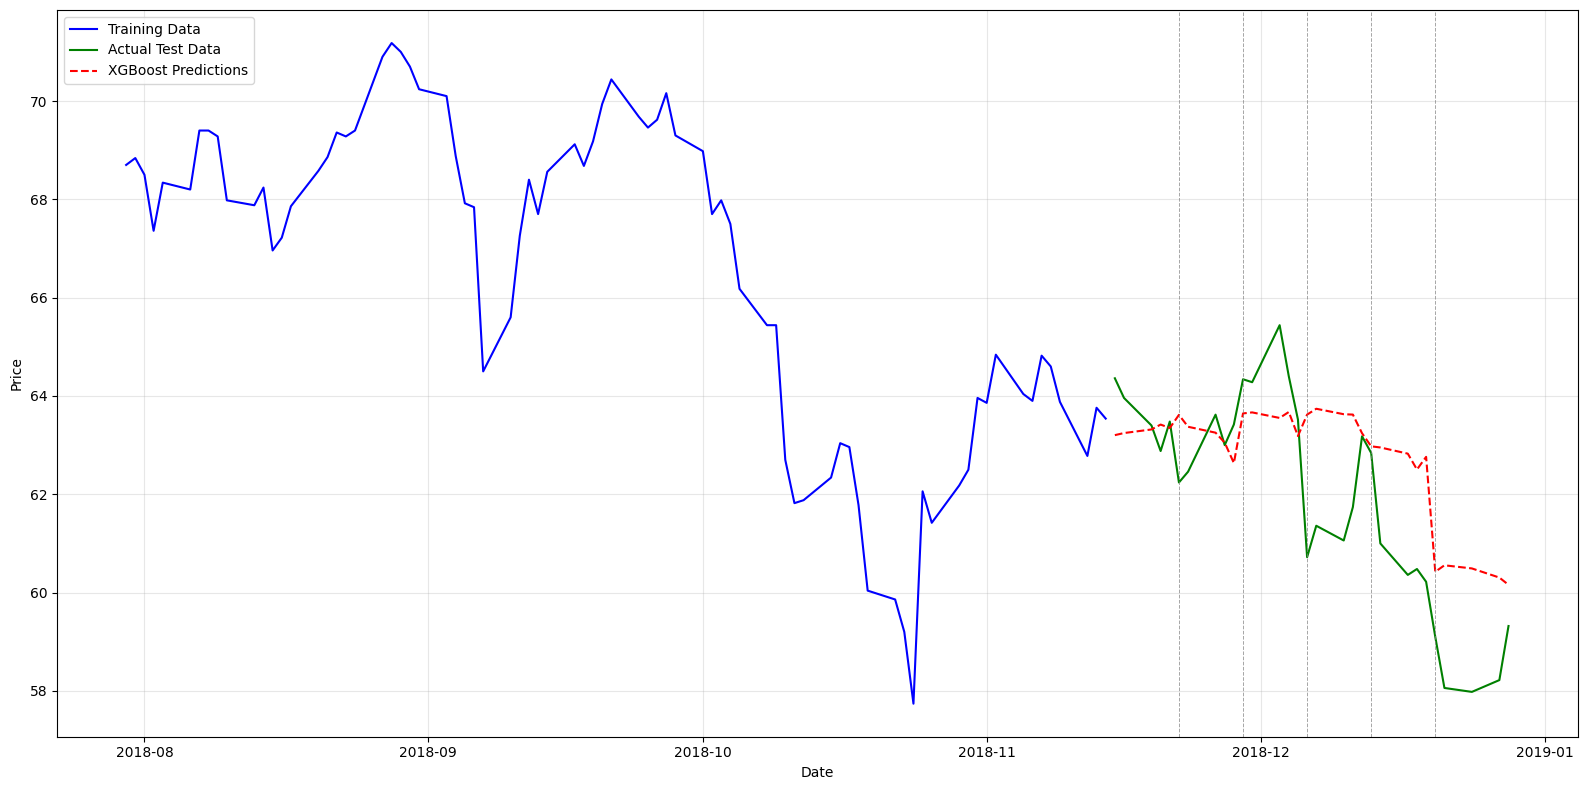

In [12]:
# ============================================
# 8. VISUALIZATION
# ============================================

print("\n--- Generating Visualization ---")

# Determine the start date for the last 5 months of data for plot
end_date_for_plot = df_stoxx.index.max()
start_date_for_plot = end_date_for_plot - pd.DateOffset(months=5)

# Filter the training and test series for the plot
train_data_plot = train_series[train_series.index >= start_date_for_plot].to_frame()
actual_test_data_plot = test_series.to_frame()
predicted_data_plot = comparison_df[['XGBoost_Predicted']]

# Show block boundaries on the plot
plt.figure(figsize=(16, 8))
plt.plot(train_data_plot.index, train_data_plot['SU_Close'], 
         label='Training Data', color='blue', linewidth=1.5)
plt.plot(actual_test_data_plot.index, actual_test_data_plot['SU_Close'], 
         label='Actual Test Data', color='green', linewidth=1.5)
plt.plot(predicted_data_plot.index, predicted_data_plot['XGBoost_Predicted'], 
         label='XGBoost Predictions', color='red', linestyle='--', linewidth=1.5)
for i in range(1, num_test_blocks):
    block_boundary = test_series.index[i * n_future_steps_per_block_val]
    plt.axvline(x=block_boundary, color='gray', linestyle='--', alpha=0.7, linewidth=0.7)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ============================================
# 9. FINAL SUMMARY
# ============================================

print("\n" + "="*50)
print("FORECASTING STRATEGY SUMMARY")
print("="*50)
print(f"Forecasting Strategy: Recursive Retraining")
print(f"Best n_lags_val identified: {best_n_lags_val}")
print(f"Fixed n_future_steps_per_block_val: {n_future_steps_per_block_val}")
print(f"\nBest XGBoost Hyperparameters:")
print(f"  n_estimators: {best_n_estimators}")
print(f"  learning_rate: {best_learning_rate}")
print(f"  max_depth: {best_max_depth}")
print(f"\nPerformance Metrics (using overall best parameters):")

# Display metrics for each horizon
for i, h in enumerate(horizons):
    if h <= len(all_actuals_flat):
        print(f"  {h}-day horizon - RMSE: {rmse_per_horizon[i]:.2f}, MAE: {mae_per_horizon[i]:.2f}")

print(f"\nOverall {len(all_actuals_flat)}-day performance:")
print(f"  RMSE: {overall_rmse:.2f}, MAE: {overall_mae:.2f}")

# Display block-by-block metrics
print(f"\nBlock-by-block training sizes:")
for metric in block_metrics:
    print(f"  Block {metric['block']}: Trained on {metric['training_size']} days")

# Display final comparison table (first few rows)
print(f"\nFirst 10 days of predictions vs actuals:")
print(comparison_df.head(10).round(2))

print("\n" + "="*60)
print("RECURSIVE RETRAINING COMPLETE")
print("="*60)


FORECASTING STRATEGY SUMMARY
Forecasting Strategy: Recursive Retraining
Best n_lags_val identified: 22
Fixed n_future_steps_per_block_val: 5

Best XGBoost Hyperparameters:
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 3

Performance Metrics (using overall best parameters):
  5-day horizon - RMSE: 0.66, MAE: 0.52
  10-day horizon - RMSE: 0.75, MAE: 0.61
  15-day horizon - RMSE: 0.84, MAE: 0.69
  20-day horizon - RMSE: 1.32, MAE: 1.01
  25-day horizon - RMSE: 1.49, MAE: 1.17
  30-day horizon - RMSE: 1.58, MAE: 1.28

Overall 30-day performance:
  RMSE: 1.58, MAE: 1.28

Block-by-block training sizes:
  Block 1: Trained on 2781 days
  Block 2: Trained on 2786 days
  Block 3: Trained on 2791 days
  Block 4: Trained on 2796 days
  Block 5: Trained on 2801 days
  Block 6: Trained on 2806 days

First 10 days of predictions vs actuals:
            Actual  XGBoost_Predicted
Date                                 
2018-11-15   64.36          63.200001
2018-11-16   63.96          63.250000
2